# Dimension classification searchlights

Visualize diagnosis classification from two subject-level feature sets:

1. **Affiliation − power:** one contrast map per subject.
2. **Affiliation + power:** the two condition maps treated as separate local channels.

The plotted values are cross-validated balanced accuracy, where **0.50 is chance**. These are unthresholded descriptive maps. Local peaks should not be interpreted as statistically significant until permutation testing and whole-brain correction are added.

In [1]:
%matplotlib inline

from pathlib import Path
import json

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn import image, plotting

RESULT_DIR = Path(
    '/Users/matty_gee/Desktop/Social/SocialCUD/results/glms/lss_decision/'
    'searchlights/statistical-maps/dimension_classification'
)

MAP_PATHS = {
    'Affiliation − power': (
        RESULT_DIR / 'affiliation_minus_power' / 'diagnosis_balanced_accuracy.nii.gz'
    ),
    'Affiliation + power': (
        RESULT_DIR / 'affiliation_and_power' / 'diagnosis_balanced_accuracy.nii.gz'
    ),
}

missing = [str(path) for path in MAP_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Missing classification maps:\n' + '\n'.join(missing))

maps = {name: nib.load(path) for name, path in MAP_PATHS.items()}
subjects = pd.read_csv(RESULT_DIR / 'subjects_and_folds.csv')
with (RESULT_DIR / 'analysis.json').open() as stream:
    configuration = json.load(stream)

configuration

{'models': ['affiliation_and_power', 'affiliation_minus_power'],
 'n_subjects': 67,
 'n_folds': 5,
 'fold_stratification': ['diagnosis', 'sex'],
 'classifier': "StandardScaler + LinearSVC(C=1, class_weight='balanced')",
 'score': 'balanced_accuracy',
 'radius_voxels': 3,
 'shape': 'ball',
 'min_active_proportion': 0.1,
 'workers': 12,
 'random_state': 2026,
 'mask': '/Users/matty_gee/Desktop/Social/SocialCUD/results/glms/lss_decision/voxelwise/dimension_average/grey_matter_mask.nii.gz'}

In [2]:
# Both models must cover the same searchlight centers on the same grid.
reference = next(iter(maps.values()))
reference_finite = np.isfinite(reference.get_fdata())
for name, img in maps.items():
    if img.shape != reference.shape or not np.allclose(img.affine, reference.affine):
        raise ValueError(f'{name} is not aligned to the reference map')
    if not np.array_equal(np.isfinite(img.get_fdata()), reference_finite):
        raise ValueError(f'{name} does not contain the same valid centers')

print(f'Subjects: {len(subjects)}')
print(f'Valid searchlight centers: {reference_finite.sum():,}')
display(subjects.groupby(['dx', 'sex']).size().rename('n').to_frame())

Subjects: 67
Valid searchlight centers: 174,621


n
dx sex    
0  0    16
   1    20
1  0    26
   1     5

In [3]:
# Summarize balanced accuracy over all valid gray-matter centers.
summary_rows = []
for name, img in maps.items():
    values = img.get_fdata()[reference_finite]
    summary_rows.append(
        {
            'model': name,
            'mean': values.mean(),
            'sd': values.std(),
            'minimum': values.min(),
            'maximum': values.max(),
            'proportion_above_chance': (values > 0.50).mean(),
        }
    )

summary = pd.DataFrame(summary_rows).set_index('model')
summary.round(3)

,mean,sd,minimum,maximum,proportion_above_chance
model,,,,,
Affiliation − power,0.496,0.072,0.196,0.813,0.479
Affiliation + power,0.498,0.073,0.208,0.818,0.490


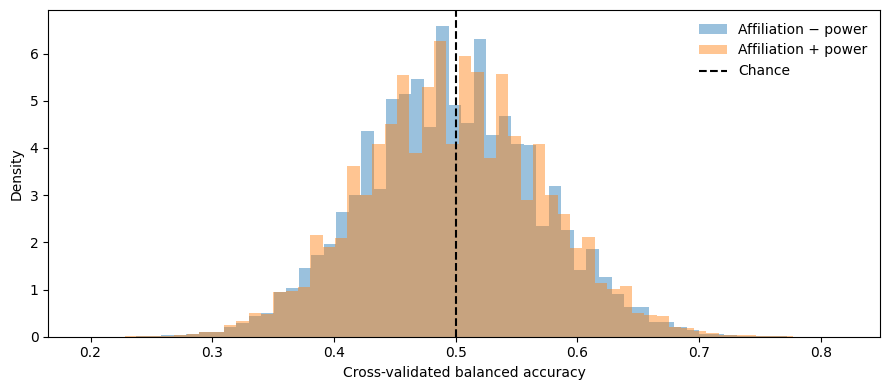

In [4]:
# Distribution of searchlight scores. Voxels are spatially dependent, so
# this is a descriptive display rather than an inferential histogram.
fig, ax = plt.subplots(figsize=(9, 4))
for name, img in maps.items():
    values = img.get_fdata()[reference_finite]
    ax.hist(values, bins=60, density=True, alpha=0.45, label=name)
ax.axvline(0.50, color='black', linestyle='--', linewidth=1.5, label='Chance')
ax.set(xlabel='Cross-validated balanced accuracy', ylabel='Density')
ax.legend(frameon=False)
fig.tight_layout()

/Users/matty_gee/miniconda3/envs/social_cud/lib/python3.11/site-packages/nilearn/plotting/img_plotting.py:1416: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  safe_get_data(stat_map_img, ensure_finite=True),
/var/folders/6j/97qtbfv55979kc8p1nz6008r0000gn/T/ipykernel_92708/3820740099.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


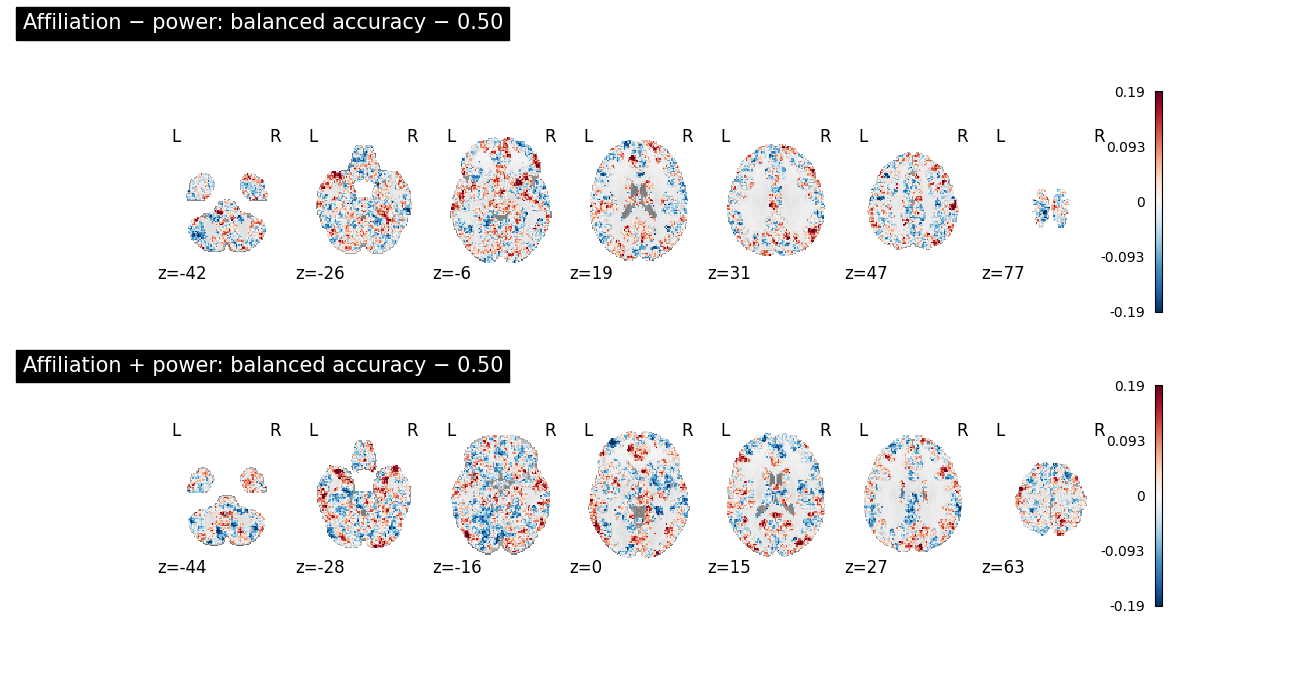

In [5]:
# Center maps at chance so red means above 0.50 and blue means below 0.50.
centered_maps = {
    name: image.math_img('accuracy - 0.5', accuracy=img)
    for name, img in maps.items()
}
all_centered = np.concatenate(
    [img.get_fdata()[reference_finite] for img in centered_maps.values()]
)
shared_vmax = float(np.quantile(np.abs(all_centered), 0.99))

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for axis, (name, img) in zip(axes, centered_maps.items()):
    plotting.plot_stat_map(
        img,
        axes=axis,
        display_mode='z',
        cut_coords=7,
        cmap='RdBu_r',
        symmetric_cbar=True,
        threshold=0,
        vmax=shared_vmax,
        title=f'{name}: balanced accuracy − 0.50',
    )
fig.tight_layout()

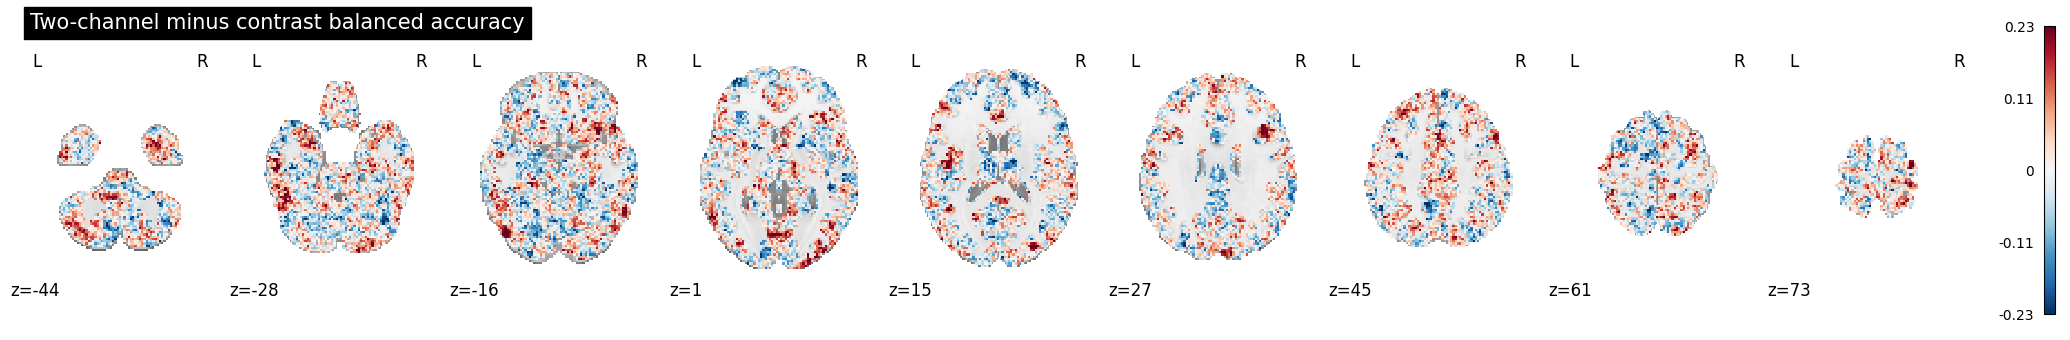

In [6]:
# Descriptive paired difference between the two performance maps.
difference = image.math_img(
    'two_channel - contrast',
    two_channel=maps['Affiliation + power'],
    contrast=maps['Affiliation − power'],
)
difference_values = difference.get_fdata()[reference_finite]
difference_vmax = float(np.quantile(np.abs(difference_values), 0.99))

plotting.plot_stat_map(
    difference,
    display_mode='z',
    cut_coords=9,
    cmap='RdBu_r',
    symmetric_cbar=True,
    threshold=0,
    vmax=difference_vmax,
    title='Two-channel minus contrast balanced accuracy',
)

## Optional interactive view

This view applies a descriptive threshold of ±0.05 around chance for easier exploration. It is not a statistical threshold.

In [9]:
centered_maps.keys()

dict_keys(['Affiliation − power', 'Affiliation + power'])

/Users/matty_gee/miniconda3/envs/social_cud/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



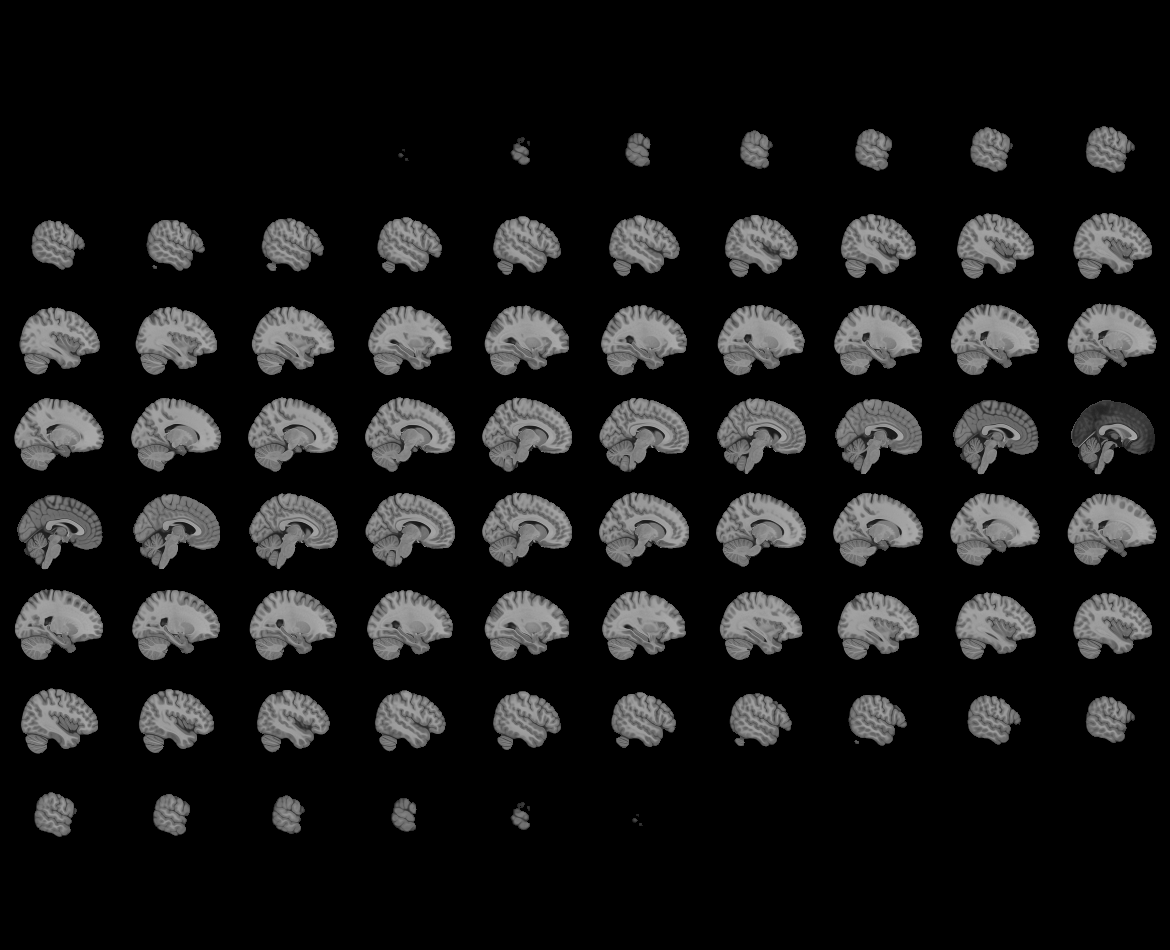
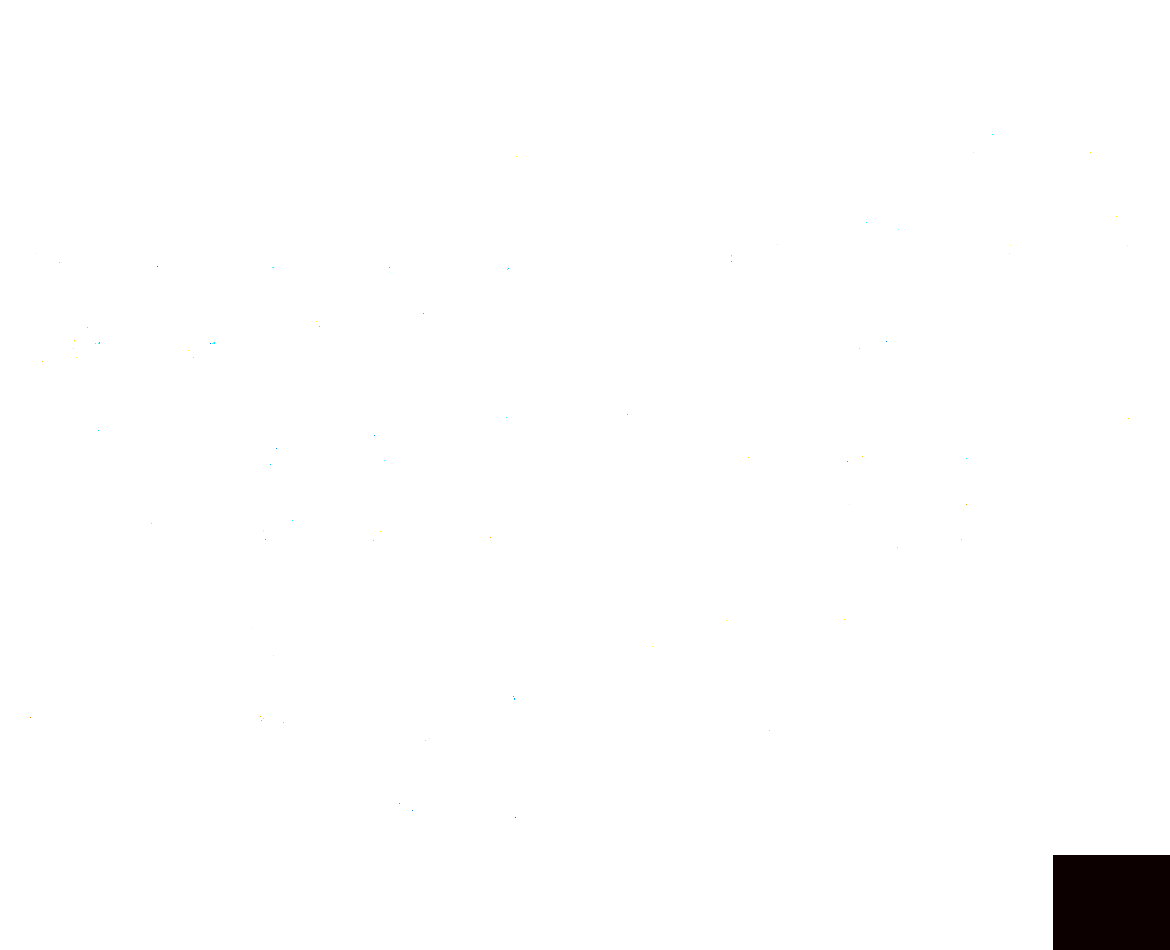

In [14]:
MODEL_TO_EXPLORE = 'Affiliation + power'
plotting.view_img(
    centered_maps[MODEL_TO_EXPLORE],
    threshold=0.25,
    cmap='cold_hot',
    symmetric_cmap=True,
    title=f'{MODEL_TO_EXPLORE}: balanced accuracy − 0.50',
)